Connected to hyriver-dev (Python 3.12.5)

 Phase 4: Dynamic Landslide Exposure Monte Carlo Simulation
 1,000 Iterations of Vectorized Bayesian Sampling

1) Loading the Monte Carlo Engine...
2) Preparing Cumulative Distribution Functions (CDF)...
3) Running 1000 Monte Carlo Iterations...


Simulating Exposure: 100%|██████████| 1000/1000 [07:51<00:00,  2.12it/s]



4) Calculating Statistical Bounds (Mean, 5th, 95th Percentiles)...
5) Plotting Dynamic Landslide Exposure...


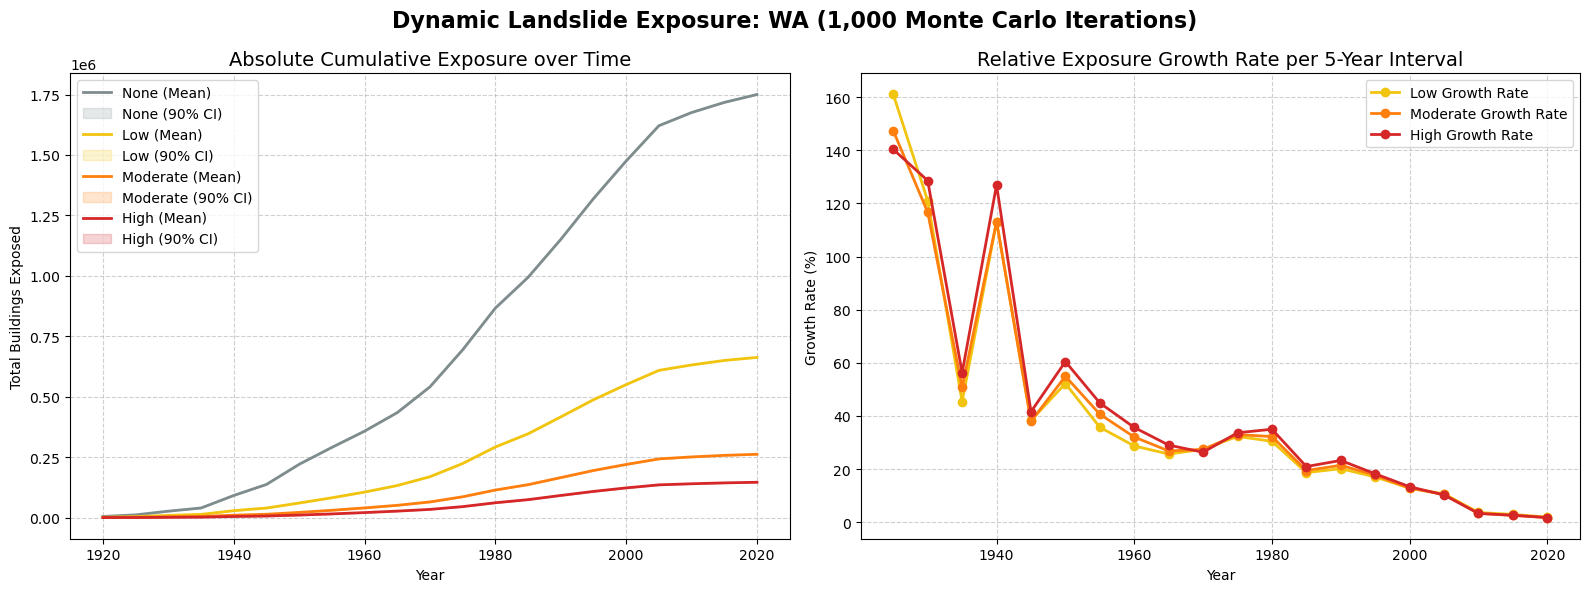


6) Exporting Final Monte Carlo Results...
SUCCESS! Results saved to /Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data/Testing_Set/WA_Monte_Carlo_Exposure_Results.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# --- Setup Paths ---
DATA_PATH = Path("/Users/danielacosta/Library/CloudStorage/OneDrive-UW/0 - DA General Exam/Paper 2 - Temporal Dynamics/Data")
TESTING_SET_PATH = DATA_PATH / "Testing_Set"
state_code = "WA"
N_ITERATIONS = 1000
YEARS = np.arange(1920, 2025, 5)

print("1) Loading the Monte Carlo Engine...")
led_engine_path = TESTING_SET_PATH / f"{state_code}_LED_Monte_Carlo_Engine.parquet"
led_df = pd.read_parquet(led_engine_path)

# Ensure the susceptibility class is present. If it was dropped during previous merges,
# you would need to merge it back here from your original spatial file using the building ID.
if 'susc_class' not in led_df.columns:
    raise KeyError("The column 'susc_class' was not found in the Monte Carlo Engine. Please merge it before proceeding.")

# Clean up any potential casing issues (e.g., 'High' vs 'high')
led_df['susc_class'] = led_df['susc_class'].astype(str).str.lower().str.strip()

# Define our exact hazard classes based on your inventory
hazard_classes = ['none', 'low', 'moderate', 'high']
n_hazards = len(hazard_classes)

# --- 2) Prepare the Vectorized Math ---
print("2) Preparing Cumulative Distribution Functions (CDF)...")
# Extract the (2.8M, 21) probability matrix
prob_matrix = np.stack(led_df['prob_distribution'].values)

# Calculate the CDF. This turns [0.1, 0.5, 0.4] into [0.1, 0.6, 1.0]
cdf_matrix = np.cumsum(prob_matrix, axis=1)

# Force the final column to be exactly 1.0 to prevent floating-point rounding errors
cdf_matrix[:, -1] = 1.0 

# Extract the hazard classes as an array for ultra-fast grouping inside the loop
hazard_array = led_df['susc_class'].values

# Create a 3D storage array: (Iterations, Hazard Classes, Time Bins)
simulation_results = np.zeros((N_ITERATIONS, n_hazards, len(YEARS)))

# --- 3) The Monte Carlo Loop ---
print(f"3) Running {N_ITERATIONS} Monte Carlo Iterations...")

for i in tqdm(range(N_ITERATIONS), desc="Simulating Exposure"):
    
    # 1. Generate random numbers between 0.0 and 1.0 for every building simultaneously
    rand_vals = np.random.rand(len(led_df), 1)
    
    # 2. Vectorized Sampling: Find the first bin where CDF >= the random number
    assigned_indices = np.argmax(cdf_matrix >= rand_vals, axis=1)
    
    # 3. Aggregate by Hazard Class using pandas crosstab for speed
    iter_df = pd.DataFrame({
        'hazard': hazard_array,
        'year_idx': assigned_indices
    })
    
    counts = pd.crosstab(iter_df['hazard'], iter_df['year_idx'])
    
    # Ensure all 21 columns (0 to 20) exist, even if a year had 0 buildings
    counts = counts.reindex(columns=range(21), fill_value=0)
    
    # Reorder rows to match our hazard_classes list exactly
    counts = counts.reindex(index=hazard_classes, fill_value=0)
    
    # 4. Convert deltas to Cumulative Exposure and store in our 3D array
    cumulative_exposure = np.cumsum(counts.values, axis=1)
    simulation_results[i, :, :] = cumulative_exposure

# --- 4) Calculate Confidence Intervals ---
print("\n4) Calculating Statistical Bounds (Mean, 5th, 95th Percentiles)...")

# Calculate metrics across the Iteration axis (axis=0)
mean_exposure = np.mean(simulation_results, axis=0)
lower_bound = np.percentile(simulation_results, 5, axis=0)  # 90% Confidence Lower
upper_bound = np.percentile(simulation_results, 95, axis=0) # 90% Confidence Upper

# --- 5) Visualizing Dynamic Exposure ---
print("5) Plotting Dynamic Landslide Exposure...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Dynamic Landslide Exposure: {state_code} (1,000 Monte Carlo Iterations)", fontsize=16, fontweight='bold')

# Formal color mapping for the hazard classes
color_map = {
    'high': '#d62728',      # Red
    'moderate': '#ff7f0e',  # Orange
    'low': '#f1c40f',       # Yellow
    'none': '#7f8c8d'       # Gray
}

# Plot 1: Absolute Exposure (Cumulative)
for h_idx, hazard in enumerate(hazard_classes):
    color = color_map.get(hazard, '#1f77b4')
    
    # Plot the Mean line
    ax1.plot(YEARS, mean_exposure[h_idx, :], label=f"{hazard.capitalize()} (Mean)", color=color, linewidth=2)
    
    # Plot the Shaded Confidence Interval
    ax1.fill_between(
        YEARS, 
        lower_bound[h_idx, :], 
        upper_bound[h_idx, :], 
        color=color, alpha=0.2, label=f"{hazard.capitalize()} (90% CI)"
    )

ax1.set_title('Absolute Cumulative Exposure over Time', fontsize=14)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Buildings Exposed')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Relative Exposure Growth Rates (The First Derivative)
growth_rates = np.zeros((n_hazards, len(YEARS)-1))
for h_idx in range(n_hazards):
    # Delta (New buildings) / Previous Total = Growth Rate
    deltas = np.diff(mean_exposure[h_idx, :])
    prev_totals = np.where(mean_exposure[h_idx, :-1] == 0, 1, mean_exposure[h_idx, :-1])
    growth_rates[h_idx, :] = (deltas / prev_totals) * 100

for h_idx, hazard in enumerate(hazard_classes):
    # Ignore the 'none' baseline to clearly see how the actual hazard zones are growing
    if hazard != 'none':
        color = color_map.get(hazard, '#1f77b4')
        ax2.plot(YEARS[1:], growth_rates[h_idx, :], marker='o', label=f"{hazard.capitalize()} Growth Rate", color=color, linewidth=2)

ax2.set_title('Relative Exposure Growth Rate per 5-Year Interval', fontsize=14)
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth Rate (%)')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 6) Export the Final Data ---
print("\n6) Exporting Final Monte Carlo Results...")
output_records = []
for h_idx, hazard in enumerate(hazard_classes):
    for y_idx, year in enumerate(YEARS):
        output_records.append({
            'Hazard_Class': hazard,
            'Year': year,
            'Mean_Expected_Buildings': mean_exposure[h_idx, y_idx],
            'Lower_5th_Percentile': lower_bound[h_idx, y_idx],
            'Upper_95th_Percentile': upper_bound[h_idx, y_idx]
        })

final_results_df = pd.DataFrame(output_records)
out_csv_path = TESTING_SET_PATH / f"{state_code}_Monte_Carlo_Exposure_Results.csv"
final_results_df.to_csv(out_csv_path, index=False)
print(f"SUCCESS! Results saved to {out_csv_path}")